<a href="https://colab.research.google.com/github/Top-Nuttawat/Statistical-Mechanics-and-simulations-with-python/blob/main/02_Romeo_%26_Juliet_Love_Dynamics_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💕 Romeo & Juliet Love Dynamics Model  
## แบบจำลองพลวัตความรัก (Love Model )  เชิงคณิตศาสตร์

---

## 1) Introduction

แบบจำลองนี้อธิบายการเปลี่ยนแปลงของความรู้สึกระหว่าง Romeo และ Juliet
โดยใช้ **สมการเชิงอนุพันธ์ไม่เชิงเส้นแบบมีดีเลย์ (Nonlinear Delay Differential Equations)**

แนวคิดหลักคือ:

- ความรักจืดจางได้เองตามเวลา
- ความรู้สึกของเราได้รับอิทธิพลจากความรู้สึกของอีกฝ่าย
- ได้รับอิทธิพลจากเสน่ห์ (appeal) ซึ่งเสมือนเป็นแรงดึงดูดที่คงที่
- มีเวลาหน่วง (delay) ในการตอบสนอง

---


## 2) นิยามตัวแปร

กำหนดให้

- $x_1(t)$ = ความรู้สึก(รัก)ของ Romeo ที่เป็นฟังก์ชันของ เวลา  $t$  
- $x_2(t)$ = ความรู้สึก(รัก)ของ Juliet ที่เป็นฟังก์ชันของ เวลา  $t$  

พารามิเตอร์ของระบบ:

- $\lambda_1, \lambda_2$ = อัตราความจืดจางของความรัก  
- $b_1, b_2$ = การตอบสนองต่อความรู้สึกของอีกฝ่าย  
- $r_1, r_2$ = การตอบสนองต่อเสน่ห์  
- $\text{app}_1, \text{app}_2$ = เสน่ห์  
- $\tau_1, \tau_2$ =การเก็บความรู้สึก[เวลาหน่วง (delay)] การตอบสนองของมนุษย์ไม่เกิดขึ้นทันที
เรามี “เวลาหน่วง” ในการประมวลผลความรู้สึก


---
## 3) สมการเชิงอนุพันธ์ของแบบจำลองพลวัตความรัก Love Dynamics Model  

<br><br>

$$
\frac{dx_1}{dt}
=
- \lambda_1 x_1(t)
+ b_1 \tanh\!\left(x_2(t-\tau_1)\right)
+ r_1 \,\text{app}_2
$$

<br><br>

$$
\frac{dx_2}{dt}
=
- \lambda_2 x_2(t)
+ b_2 \tanh\!\left(x_1(t-\tau_2)\right)
+ r_2 \,\text{app}_1
$$


<br><br>

---

## 4) การแก้สมการเชิงตัวเลข (Euler Method)

ใช้วิธี Euler แบบ Forward:

$$
x(t+\Delta t)
=
x(t)
+
\frac{dx}{dt}\Delta t
$$

จึงได้รูปแบบไม่ต่อเนื่อง:
<br><br>
$$
x_1^{n+1}
=
x_1^n
-
\lambda_1 x_1^n \Delta t
+
b_1 \tanh\!\left(x_2^{n-\tau_1}\right) \Delta t
+
r_1 \text{app}_2 \Delta t
$$
<br><br>
$$
x_2^{n+1}
=
x_2^n
-
\lambda_2 x_2^n \Delta t
+
b_2 \tanh\!\left(x_1^{n-\tau_2}\right) \Delta t
+
r_2 \text{app}_1 \Delta t
$$

โดย

$$
n_\tau = \frac{\tau}{\Delta t}
$$


<br>


---





In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def RJ() :
    # 1 : Romeo and 2 : Juliet
    x1 = np.zeros( nstep + 1 )
    x2 = np.zeros( nstep + 1 )

    # initial conditions
    ntau1  =  int(tau1/dt)
    ntau2  =  int(tau2/dt)
    x1[0] = x1_0
    x2[0] = x2_0

    # Euler method
    for  i  in  range(0 ,  nstep ):
        i1 = max( 0 , i-ntau1 )
        i2 = max( 0 , i-ntau2 )

        x1[i + 1] = x1[i] - lambda1*x1[i]*dt  + b1*np.tanh(x2[i2])*dt + r1*app2*dt
        x2[i + 1] = x2[i] - lambda2*x2[i]*dt  + b2*np.tanh(x1[i1])*dt + r2*app1*dt

    #plot
    fig, ax = plt.subplots()
    ax.set_ylabel("Love")
    ax.set_xlabel("time  (arbitrary unit)" )
    ax.plot(x1, label='Romeo', linewidth=2)
    ax.plot(x2, label='Juliet', linewidth=2)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.title("Romeo and Juliet's Feelings as a Function of Time")
    plt.show()


    ntau = max( ntau1, ntau2 )
    fig, ax = plt.subplots()
    ax.set_ylabel(" Juliet ")
    ax.set_xlabel(" Romeo")
    ax.plot(  x1[ntau : ] , x2[ntau:] )
    ax.plot(  x1[ntau1] , x2[ntau] , 'ro')
    plt.show()


ปรับค่า Parameter :

In [ ]:
# run parameters

dt = 0.001   # Delta t
nstep = 60000 # Number of steps
# ความจืดจาง ,  การตอบสนองต่อความรู้สึกฝ่ายตรงข้าม , การตอบสนองต่อสเน่ห์ , สเน่ห์ ,การเก็บความรู้สึก

[  lambda1 , b1 , r1 , app1 , tau1 ] = [ 1 , 1.5 , 1 , 0.5 , 1.5] #Romeo

[  lambda2,  b2 , r2,  app2 , tau2] = [1, -1.5 , 1 , 0.3 , 1.5 ]  #Juliet

# initial conditions
x1_0 = 0.5
x2_0 = 0.5

RJ()

In [ ]:
# run parameters

dt = 0.001   # Delta t
nstep = 60000 # Number of steps
# ความจืดจาง ,  การตอบสนองต่อความรู้สึกฝ่ายตรงข้าม , การตอบสนองต่อสเน่ห์ , สเน่ห์ ,การเก็บความรู้สึก

[  lambda1 , b1 , r1 , app1 , tau1 ] = [ 1 , 1.5 , 1 , 0.5 , 1.5] #Romeo

[  lambda2,  b2 , r2,  app2 , tau2] = [2, -1.5 , 1 , 0.3 , 1.5 ]  #Juliet

# initial conditions
x1_0 = 0.5
x2_0 = 0.5

RJ()

##Phase Space Analysis

กราฟ $x_2$ vs $x_1$ เรียกว่า **Phase Plot**

ใช้วิเคราะห์ว่า:

- ระบบเข้าสู่จุดสมดุลหรือไม่  
- มีวงโคจร (limit cycle) หรือไม่  
- พฤติกรรมเสถียรหรือไม่  

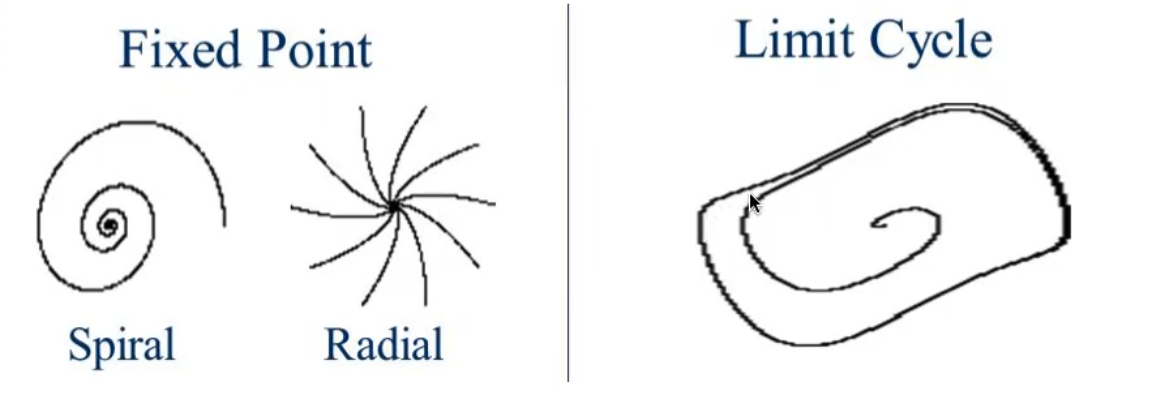

---